# Car Performance Analysis using mtcars Dataset

## Part 1: Load and Understand Data

In [1]:

import pandas as pd
from pydataset import data

df = data('mtcars')
df.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [2]:

df.shape
df.columns
df.dtypes
df.describe()
df.isnull().sum()


mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

Observation: Dataset has 32 rows and 11 columns with no missing values.

## Part 2: Basic Analysis

In [3]:

df['mpg'].mean()
df['hp'].max()
df['wt'].min(), df['wt'].max()


(1.513, 5.424)

In [4]:
df['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

In [5]:
df.groupby('cyl')['mpg'].mean()

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

Observation: Cars with fewer cylinders have higher mileage.

## Part 3: Intermediate Analysis

In [6]:

df.groupby('am')['mpg'].mean()
df.groupby('gear')['mpg'].mean()


gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

In [7]:
pd.pivot_table(df, values='mpg', index='cyl', columns='am')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [8]:

df['efficiency'] = df['mpg'].apply(lambda x: 'High' if x > 20 else 'Low')
df['am'] = df['am'].map({0:'Automatic',1:'Manual'})
df['vs'] = df['vs'].map({0:'V-shaped',1:'Straight'})
df.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4,High
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4,High
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1,High
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1,High
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2,Low


Observation: Manual cars generally show better efficiency.

## Part 4: Visualization

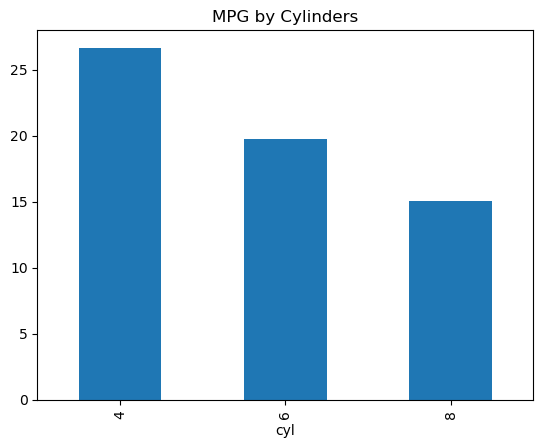

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

df.groupby('cyl')['mpg'].mean().plot(kind='bar')
plt.title('MPG by Cylinders')
plt.show()


Observation: Fewer cylinders → higher MPG

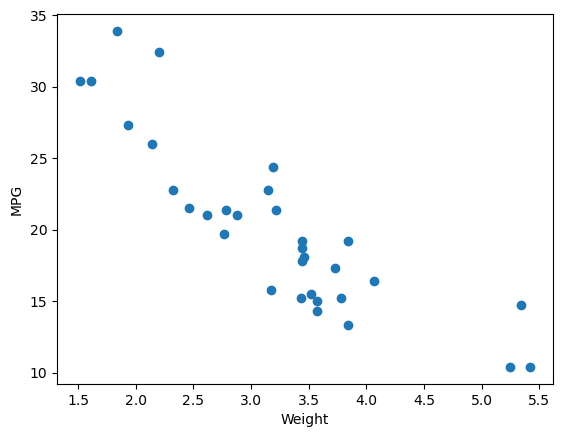

In [10]:

plt.scatter(df['wt'], df['mpg'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()


Observation: Higher weight reduces MPG

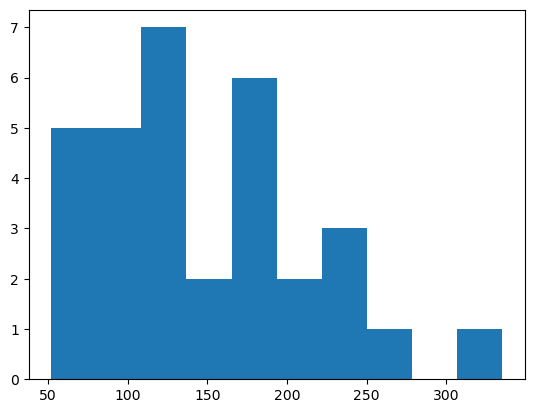

In [11]:

plt.hist(df['hp'], bins=10)
plt.show()


Observation: Most cars have medium horsepower

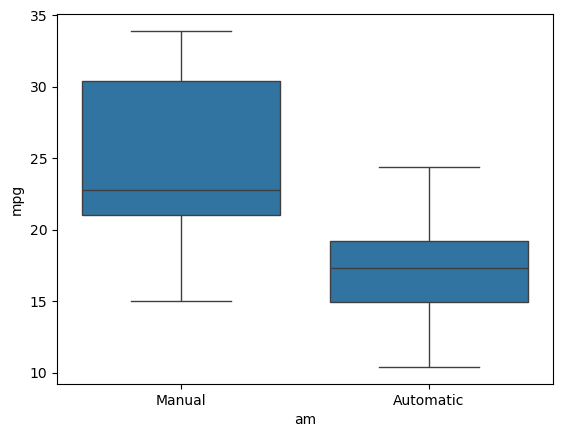

In [12]:

sns.boxplot(x='am', y='mpg', data=df)
plt.show()


Observation: Manual cars have higher MPG

## Insights


1. Cars with fewer cylinders have better mileage  
2. Lighter cars have higher MPG  
3. Manual cars perform better  
4. High horsepower reduces efficiency  
5. More gears slightly improve mileage  


## Conclusion


The analysis shows that weight, cylinders, and transmission impact fuel efficiency. 
Lighter cars with fewer cylinders and manual transmission provide better mileage.
